# cw_odmr_lock_in result: scan1-scan8

First runs taken after fixing the AWG CH1 issue (see `notes.md`'s SR830 section -- `*RST` was silently resetting CH1's continuous carrier off on every connection; `setup_ch1_carrier()` now re-configures it every run) -- from `D:\cw_odmr_lock_in\scan{1..8}`. These are the first valid runs showing the real dip.

Some points read as saturated (a value hit some level and stayed there for several consecutive frequency points -- an ADC/sensitivity clipping signature, not real signal, since real noise essentially never repeats bit-for-bit). `find_saturated_mask()` below flags these; they're plotted grayed out rather than dropped, so you can see where/how much of each scan is affected.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"D:\cw_odmr_lock_in"
RUN_NAMES = ["scan1", "scan2", "scan3", "scan4", "scan5", "scan6", "scan7", "scan8"]

runs = {}
for name in RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    reflected_dbm = np.load(f"{run_path}/{name}_lockin_spectrum_reflected_dbm.npy")
    freqs_ghz = freqs_hz / 1e9
    runs[name] = dict(freqs_ghz=freqs_ghz, x=x, y=y, r=np.hypot(x, y),
                       reflected_dbm=reflected_dbm)
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_ghz.min():.6f}-{freqs_ghz.max():.6f} GHz")

scan1: 137 points, 2.860250-2.873850 GHz
scan2: 130 points, 2.859750-2.872650 GHz


scan3: 133 points, 2.860725-2.873925 GHz
scan4: 116 points, 2.865825-2.877325 GHz
scan5: 136 points, 2.444725-2.458225 GHz


scan6: 129 points, 2.832600-2.845400 GHz
scan7: 123 points, 2.839600-2.851800 GHz


scan8: 122 points, 2.851450-2.863550 GHz


## Saturation detection

In [2]:
def find_saturated_mask(values, min_run=3):
    """
    Flag points that are part of a run of >= min_run consecutive
    (near-)identical values -- a stuck/saturated reading (ADC or
    sensitivity-range clipping), not real signal or noise: real noise
    essentially never repeats bit-for-bit for that many points in a row.
    Returns a boolean array, True where a point belongs to such a run.
    """
    values = np.asarray(values)
    n = len(values)
    mask = np.zeros(n, dtype=bool)
    if n == 0:
        return mask
    run_start = 0
    for i in range(1, n):
        if not np.isclose(values[i], values[i - 1], rtol=1e-9, atol=0):
            if i - run_start >= min_run:
                mask[run_start:i] = True
            run_start = i
    if n - run_start >= min_run:
        mask[run_start:] = True
    return mask


for name in RUN_NAMES:
    sat = find_saturated_mask(runs[name]["x"])
    runs[name]["saturated"] = sat
    print(f"{name}: {sat.sum()}/{len(sat)} points flagged saturated")

scan1: 0/137 points flagged saturated
scan2: 0/130 points flagged saturated
scan3: 0/133 points flagged saturated
scan4: 0/116 points flagged saturated
scan5: 0/136 points flagged saturated
scan6: 0/129 points flagged saturated
scan7: 0/123 points flagged saturated


scan8: 26/122 points flagged saturated


## Comparison: scan1 vs scan2 vs ... vs scan8 (saturated points grayed out)

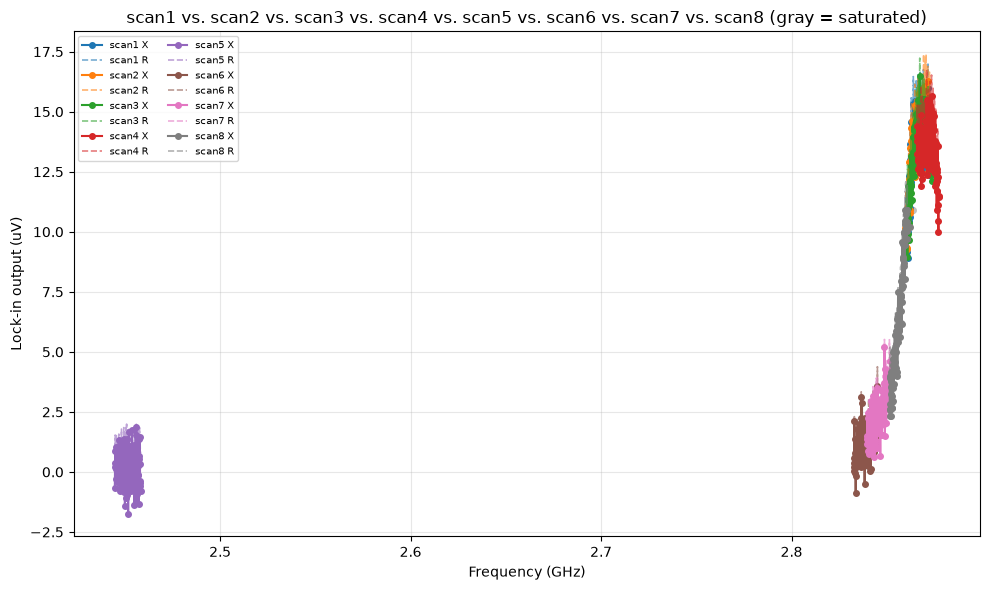

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, name in enumerate(RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs = d["freqs_ghz"]
    x_uv = d["x"] * 1e6
    r_uv = d["r"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    r_good = np.where(sat, np.nan, r_uv)
    x_bad = np.where(sat, x_uv, np.nan)
    r_bad = np.where(sat, r_uv, np.nan)

    ax.plot(freqs, x_good, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs, r_good, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")
    ax.plot(freqs, x_bad, "o", color="0.75", ms=4, zorder=1)
    ax.plot(freqs, r_bad, "--", color="0.75", lw=1.2, alpha=0.6, zorder=1)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(RUN_NAMES) + " (gray = saturated)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Zoomed comparison, scan5 excluded, frequency in MHz

`scan5` covers a completely different range (~2.4448-2.4582 GHz) from the other 7 scans (~2.833-2.878 GHz), so including it forces a wide, mostly-empty x-axis. This plot drops `scan5` and zooms into the region the remaining scans actually share, with frequency in MHz instead of GHz.

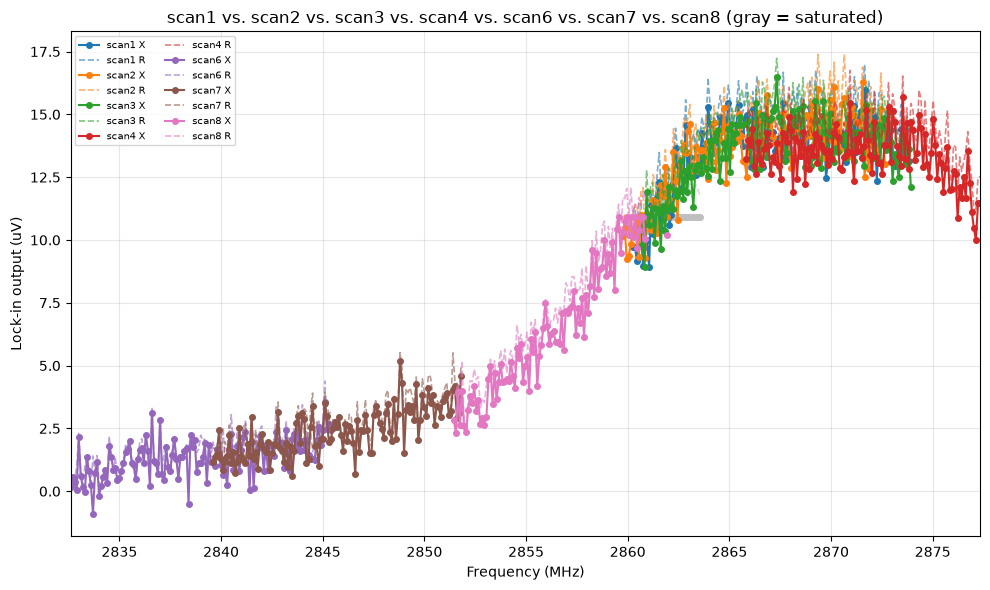

In [4]:
ZOOM_RUN_NAMES = [n for n in RUN_NAMES if n != "scan5"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6
    r_uv = d["r"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    r_good = np.where(sat, np.nan, r_uv)
    x_bad = np.where(sat, x_uv, np.nan)
    r_bad = np.where(sat, r_uv, np.nan)

    ax.plot(freqs_mhz, x_good, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs_mhz, r_good, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")
    ax.plot(freqs_mhz, x_bad, "o", color="0.75", ms=4, zorder=1)
    ax.plot(freqs_mhz, r_bad, "--", color="0.75", lw=1.2, alpha=0.6, zorder=1)

all_freqs_mhz = np.concatenate([runs[n]["freqs_ghz"] * 1e3 for n in ZOOM_RUN_NAMES])
ax.set_xlim(all_freqs_mhz.min(), all_freqs_mhz.max())
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(ZOOM_RUN_NAMES) + " (gray = saturated)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Lorentzian fit (per scan, scan5 excluded), FWHM

Fits a Lorentzian dip to each scan's X data (saturated points excluded from the fit) to extract the center frequency and FWHM.

In [5]:
from scipy.optimize import curve_fit

def lorentzian_dip(f, baseline, amplitude, center, fwhm):
    return baseline - amplitude * (fwhm / 2) ** 2 / ((f - center) ** 2 + (fwhm / 2) ** 2)


fit_results = {}
for name in ZOOM_RUN_NAMES:
    d = runs[name]
    good = ~d["saturated"]
    freqs_mhz = d["freqs_ghz"][good] * 1e3
    x_uv = d["x"][good] * 1e6

    baseline_guess = np.median(np.concatenate([x_uv[:5], x_uv[-5:]]))
    dip_idx = np.argmin(x_uv) if abs(x_uv.min() - baseline_guess) > abs(x_uv.max() - baseline_guess) \
        else np.argmax(x_uv)
    center_guess = freqs_mhz[dip_idx]
    amplitude_guess = baseline_guess - x_uv[dip_idx]
    span_mhz = freqs_mhz.max() - freqs_mhz.min()
    fwhm_guess = span_mhz / 10

    try:
        popt, pcov = curve_fit(
            lorentzian_dip, freqs_mhz, x_uv,
            p0=[baseline_guess, amplitude_guess, center_guess, fwhm_guess],
            maxfev=10000,
        )
        baseline_fit, amplitude_fit, center_fit, fwhm_fit = popt
        perr = np.sqrt(np.diag(pcov))
        fit_results[name] = dict(popt=popt, perr=perr, freqs_mhz=freqs_mhz, x_uv=x_uv)
        print(f"{name}: center = {center_fit:.4f} +/- {perr[2]:.4f} MHz, "
              f"FWHM = {abs(fwhm_fit):.4f} +/- {perr[3]:.4f} MHz")
    except RuntimeError as e:
        print(f"{name}: fit failed ({e})")

scan1: center = 2868.8168 +/- 0.2081 MHz, FWHM = 1673.6494 +/- 386183.9515 MHz
scan2: center = 2868.7839 +/- 0.3196 MHz, FWHM = 1518.0798 +/- 301014.0320 MHz
scan3: center = 2868.8469 +/- 0.1988 MHz, FWHM = 1559.4381 +/- 325220.2129 MHz
scan4: center = 2870.4236 +/- 0.3281 MHz, FWHM = 1293.3432 +/- 507690.1158 MHz
scan6: center = 2718.2704 +/- 39729.9192 MHz, FWHM = 2343.9407 +/- 9597324.1155 MHz
scan7: center = 2855.3032 +/- 11.5957 MHz, FWHM = 19.1158 +/- 19.6195 MHz
scan8: center = 2850.1597 +/- 1.8466 MHz, FWHM = 27.1222 +/- 12.6459 MHz


## Zoomed comparison with Lorentzian fits overlaid

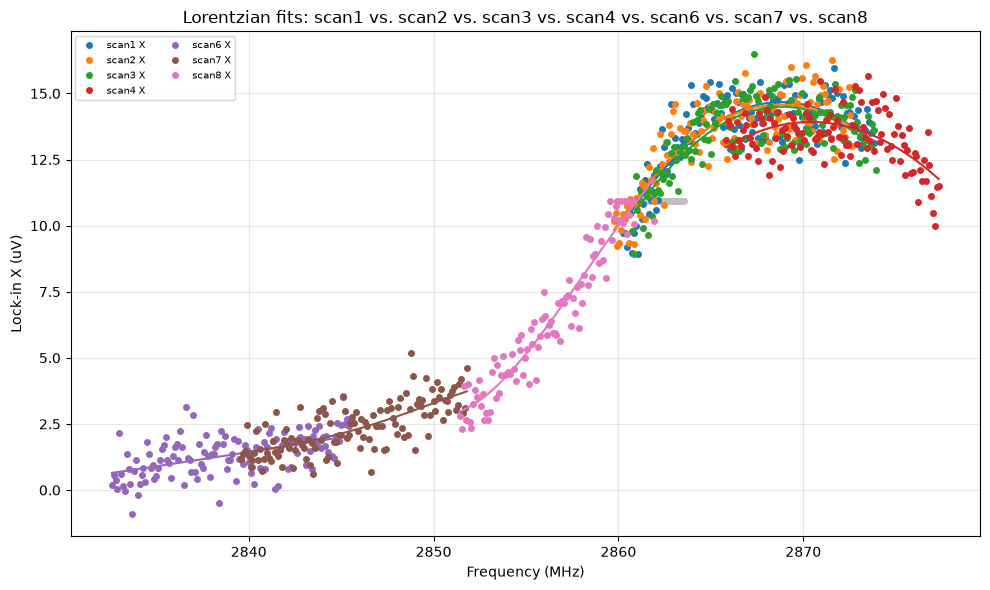

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    x_bad = np.where(sat, x_uv, np.nan)

    ax.plot(freqs_mhz, x_good, "o", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs_mhz, x_bad, "o", color="0.75", ms=4, zorder=1)

    if name in fit_results:
        fr = fit_results[name]
        f_fine = np.linspace(fr["freqs_mhz"].min(), fr["freqs_mhz"].max(), 400)
        ax.plot(f_fine, lorentzian_dip(f_fine, *fr["popt"]), "-", color=color, lw=1.5)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("Lorentzian fits: " + " vs. ".join(ZOOM_RUN_NAMES))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Combined fit: all scans except scan5, single Lorentzian

Pools every non-saturated point from all of `ZOOM_RUN_NAMES` into one dataset (sorted by frequency) and fits a single Lorentzian, instead of fitting each scan separately.

In [7]:
combined_freqs_mhz = np.concatenate([
    runs[name]["freqs_ghz"][~runs[name]["saturated"]] * 1e3
    for name in ZOOM_RUN_NAMES
])
combined_x_uv = np.concatenate([
    runs[name]["x"][~runs[name]["saturated"]] * 1e6
    for name in ZOOM_RUN_NAMES
])

order = np.argsort(combined_freqs_mhz)
combined_freqs_mhz = combined_freqs_mhz[order]
combined_x_uv = combined_x_uv[order]

print(f"{len(combined_freqs_mhz)} combined points, "
      f"{combined_freqs_mhz.min():.4f}-{combined_freqs_mhz.max():.4f} MHz")

baseline_guess = np.median(np.concatenate([combined_x_uv[:10], combined_x_uv[-10:]]))
dip_idx = np.argmin(combined_x_uv) if abs(combined_x_uv.min() - baseline_guess) > abs(combined_x_uv.max() - baseline_guess) \
    else np.argmax(combined_x_uv)
center_guess = combined_freqs_mhz[dip_idx]
amplitude_guess = baseline_guess - combined_x_uv[dip_idx]
span_mhz = combined_freqs_mhz.max() - combined_freqs_mhz.min()
fwhm_guess = span_mhz / 10

combined_popt, combined_pcov = curve_fit(
    lorentzian_dip, combined_freqs_mhz, combined_x_uv,
    p0=[baseline_guess, amplitude_guess, center_guess, fwhm_guess],
    maxfev=20000,
)
combined_perr = np.sqrt(np.diag(combined_pcov))
baseline_fit, amplitude_fit, center_fit, fwhm_fit = combined_popt

print(f"combined fit: baseline = {baseline_fit:.4f} +/- {combined_perr[0]:.4f} uV")
print(f"combined fit: amplitude = {amplitude_fit:.4f} +/- {combined_perr[1]:.4f} uV")
print(f"combined fit: center = {center_fit:.4f} +/- {combined_perr[2]:.4f} MHz")
print(f"combined fit: FWHM = {abs(fwhm_fit):.4f} +/- {combined_perr[3]:.4f} MHz")

864 combined points, 2832.6000-2877.3250 MHz
combined fit: baseline = -1.9442 +/- 0.1571 uV
combined fit: amplitude = -16.6479 +/- 0.1451 uV
combined fit: center = 2869.2129 +/- 0.0877 MHz
combined fit: FWHM = 27.9491 +/- 0.5351 MHz


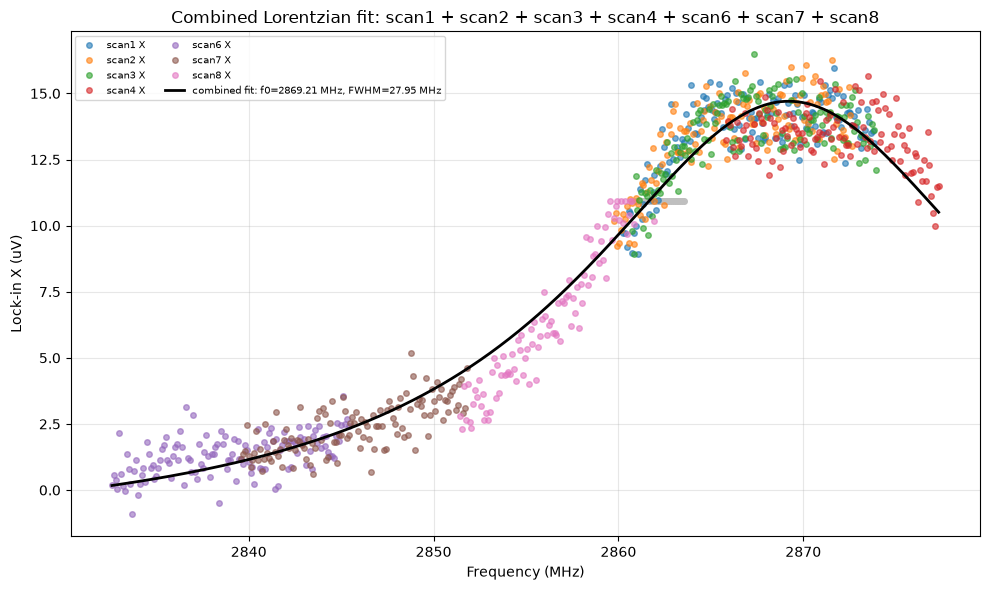

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6
    ax.plot(freqs_mhz[~sat], x_uv[~sat], "o", color=color, ms=4, alpha=0.6, label=f"{name} X")
    ax.plot(freqs_mhz[sat], x_uv[sat], "o", color="0.75", ms=4, zorder=1)

f_fine = np.linspace(combined_freqs_mhz.min(), combined_freqs_mhz.max(), 600)
ax.plot(f_fine, lorentzian_dip(f_fine, *combined_popt), "k-", lw=2,
        label=f"combined fit: f0={center_fit:.2f} MHz, FWHM={abs(fwhm_fit):.2f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("Combined Lorentzian fit: " + " + ".join(ZOOM_RUN_NAMES))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerstudy1 (-20 dBm, averaged)

First power-dependence run (`sweep-average` with `drive_power_dbm_list`) -- from `D:\cw_odmr_lock_in\powerstudy1`. Only the -20 dBm power level completed (10/10 repeats averaged).

In [9]:
run_path_ps1 = r"D:\cw_odmr_lock_in\powerstudy1"
name_ps1 = "powerstudy1_pm20dBm"

freqs_hz_ps1 = np.load(f"{run_path_ps1}/{name_ps1}_avg_freqs_hz.npy")
x_ps1 = np.load(f"{run_path_ps1}/{name_ps1}_avg_x.npy")
y_ps1 = np.load(f"{run_path_ps1}/{name_ps1}_avg_y.npy")
r_ps1 = np.load(f"{run_path_ps1}/{name_ps1}_avg_r.npy")

with open(f"{run_path_ps1}/{name_ps1}_avg_metadata.txt") as fh:
    print(fh.read())

freqs_ghz_ps1 = freqs_hz_ps1 / 1e9
print(f"{len(freqs_hz_ps1)} points, {freqs_ghz_ps1.min():.6f}-{freqs_ghz_ps1.max():.6f} GHz")

start_hz=2825625000.0
stop_hz=2839175000.0
step_hz=100000.0
n_repeats_requested=10
n_repeats_averaged=10
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=1e-05
phase_deg=0.0
drive_power_dbm=-20.0

136 points, 2.825625-2.839125 GHz


## Averaged lock-in X/Y/R vs. frequency

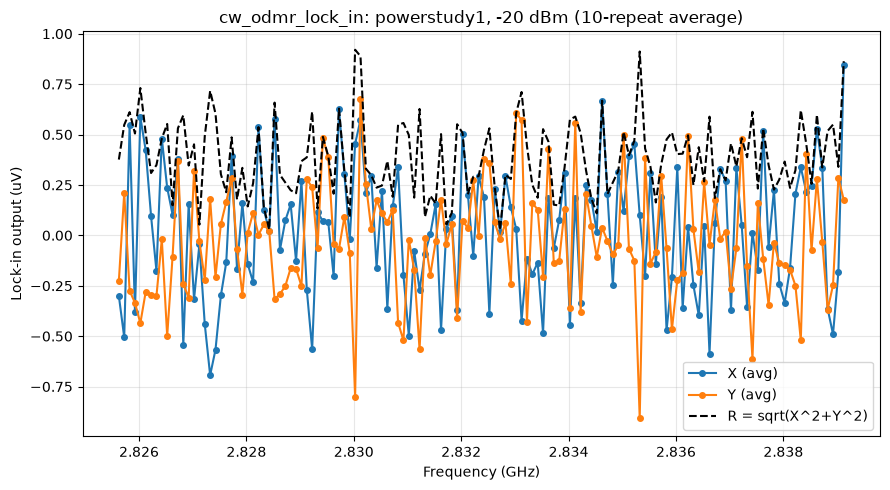

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(freqs_ghz_ps1, x_ps1 * 1e6, "o-", label="X (avg)", ms=4)
ax.plot(freqs_ghz_ps1, y_ps1 * 1e6, "o-", label="Y (avg)", ms=4)
ax.plot(freqs_ghz_ps1, r_ps1 * 1e6, "k--", label="R = sqrt(X^2+Y^2)", lw=1.5)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy1, -20 dBm (10-repeat average)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerstudy3 (0 dBm, UNFINISHED)

From `D:\cw_odmr_lock_in\powerstudy3` -- only 1 of the requested 10 repeats completed at the 0 dBm power level (a 2nd repeat was started but stopped partway through -- interlock trip or Ctrl+C -- and no other power levels in the list were reached). The "average" here is really just that single completed repeat, not a true multi-repeat average -- treat it as noisier/less reliable than `powerstudy1`.

In [11]:
run_path3 = r"D:\cw_odmr_lock_in\powerstudy3"
name3 = "powerstudy3_p0dBm"

freqs_hz_3 = np.load(f"{run_path3}/{name3}_avg_freqs_hz.npy")
x3 = np.load(f"{run_path3}/{name3}_avg_x.npy")
y3 = np.load(f"{run_path3}/{name3}_avg_y.npy")
r3 = np.load(f"{run_path3}/{name3}_avg_r.npy")

with open(f"{run_path3}/{name3}_avg_metadata.txt") as fh:
    print(fh.read())

freqs_ghz_3 = freqs_hz_3 / 1e9
print(f"{len(freqs_hz_3)} points, {freqs_ghz_3.min():.6f}-{freqs_ghz_3.max():.6f} GHz")

start_hz=2825775000.0
stop_hz=2839125000.0
step_hz=100000.0
n_repeats_requested=10
n_repeats_averaged=1
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=1e-05
phase_deg=0.0
drive_power_dbm=0.0

134 points, 2.825775-2.839075 GHz


## Lock-in X/Y/R vs. frequency (1 repeat only)

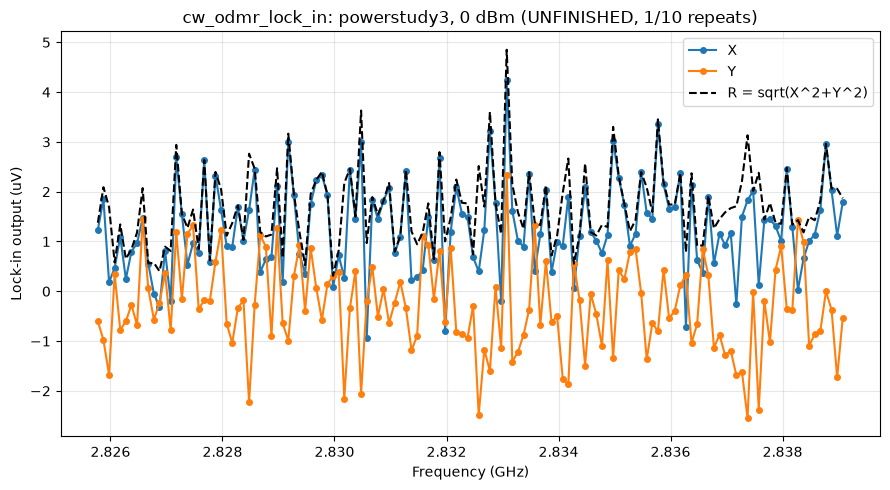

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(freqs_ghz_3, x3 * 1e6, "o-", label="X", ms=4)
ax.plot(freqs_ghz_3, y3 * 1e6, "o-", label="Y", ms=4)
ax.plot(freqs_ghz_3, r3 * 1e6, "k--", label="R = sqrt(X^2+Y^2)", lw=1.5)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy3, 0 dBm (UNFINISHED, 1/10 repeats)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()